# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_log_error

# Loading

In [2]:
train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

features = ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'FullBath',
'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF']

for n in features:
    if (train[n].isna().sum()!=0):
        train[n] = train[n].fillna(train[n].mean())

for n in features:
    if (test[n].isna().sum()!=0):
        test[n] = test[n].fillna(test[n].mean())


# Analise

In [3]:
correlacao = pd.DataFrame()
correlacao['corr'] = train.corr()['SalePrice']
correlacao['type'] = train.dtypes

In [4]:
correlacao[correlacao['corr']>=0.5]

,corr,type
OverallQual,0.790982,int64
YearBuilt,0.522897,int64
YearRemodAdd,0.507101,int64
TotalBsmtSF,0.613581,int64
1stFlrSF,0.605852,int64
GrLivArea,0.708624,int64
FullBath,0.560664,int64
TotRmsAbvGrd,0.533723,int64
GarageCars,0.640409,int64
GarageArea,0.623431,int64


In [5]:
features = ['OverallQual', 'YearBuilt', 'YearRemodAdd',
'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea']

X = train[features].copy()
y = train['SalePrice'].copy()

<AxesSubplot:>

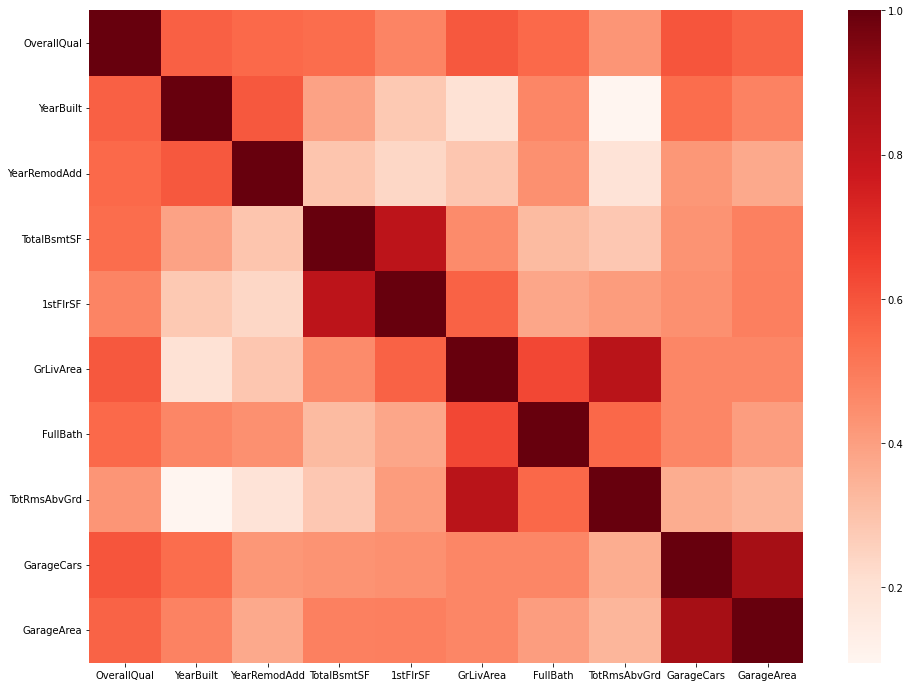

In [6]:
fig, ax = plt.subplots(figsize=(16,12))
sns.heatmap(X.corr(), cmap='Reds')

# Training

In [7]:
x_train, x_test, y_train, y_test = train_test_split( X, y, test_size=0.50, random_state=0)

## Regressão Logistica

In [8]:
model_logr = LogisticRegression(random_state=4, solver='newton-cg')
model_logr.fit( X[features],y )

/opt/conda/lib/python3.7/site-packages/sklearn/utils/optimize.py:212: ConvergenceWarning: newton-cg failed to converge. Increase the number of iterations.
  "number of iterations.", ConvergenceWarning)


LogisticRegression(random_state=4, solver='newton-cg')

In [9]:
y_pred_logr = model_logr.predict( test[features] )

In [10]:
#mse_logr = mean_squared_log_error(y_test, y_pred_logr)
#mse_logr

## Create Submission

In [11]:
# convertendo predição para coluna
sub = pd.Series(y_pred_logr, index=test['Id'], name='SalePrice')
sub.shape
sub.to_csv("modelo_logr4.csv", header=True)